# Thyroid Cancer Recurrence — Classification supervisée

**Université Paris Dauphine — M1 MA — Statistical Learning**

### Table des matières

* [0. Import et chargement des données](#chapter0)
* [1. Exploration des données (EDA)](#chapter1)
* [2. Pré-traitement des données](#chapter2)
* [3. Séparation train / test et standardisation](#chapter3)
* [4. Etude des différents modèles](#chapter4)
    * [4.1 Régression Logistique Lasso (L1)](#chapter4_1)
    * [4.2 Forêt Aléatoire (Random Forest)](#chapter4_2)
    * [4.3 Support Vector Machine (SVM)](#chapter4_3)
    * [4.4 K-Nearest Neighbors (KNN)](#chapter4_4)
* [5. Comparaison des modèles](#chapter5)
    * [5.1 Courbes ROC](#chapter5_1)
    * [5.2 Matrices de confusion](#chapter5_2)
* [6. Tableau de synthèse](#chapter6)
* [7. Conclusion](#chapter7)

---

## Introduction

### Contexte médical

Le **cancer thyroïdien différencié** (CTD) regroupe les carcinomes papillaires et folliculaires de la thyroïde. Il représente environ 90 % des cancers thyroïdiens et présente en général un bon pronostic après traitement chirurgical (thyroïdectomie) et radioiode. Cependant, **une fraction des patients — environ 20 à 30 % — connaît une récidive** de la maladie dans les années suivant le traitement initial. Détecter à l'avance les patients à risque de récidive permettrait d'adapter le suivi médical et d'intensifier la surveillance pour les profils les plus à risque.

C'est dans ce cadre que s'inscrit ce projet : construire un **modèle de classification** capable de prédire, à partir des données cliniques recueillies au moment du diagnostic et du traitement initial, si un patient récidivera ou non.

---

### Problème d'apprentissage

Il s'agit d'un problème de **classification supervisée binaire** :

- **Variable cible (output)** : `Recurred` — récidive du cancer (Yes / No)
- **Covariables (input)** : 16 variables cliniques détaillées ci-dessous
- **Taille de l'échantillon** : $n = 383$ patients, **aucune valeur manquante**
- **Déséquilibre des classes** : 275 "No" (71,8 %) et 108 "Yes" (28,2 %)

---

### Description des covariables

Les 16 variables d'entrée couvrent le profil démographique du patient, les caractéristiques tumorales et la réponse au traitement. On les regroupe en trois types selon leur nature :

#### Variables numériques continues (1)

| Variable | Description | Plage observée |
|---|---|---|
| `Age` | Âge du patient au moment du diagnostic (en années) | 15 – 82 ans, médiane 37 |

#### Variables catégorielles binaires (5)

Ces variables n'ont que deux modalités et sont encodées directement en 0/1.

| Variable | Modalités | Signification |
|---|---|---|
| `Gender` | F / M | Genre du patient |
| `Smoking` | No / Yes | Tabagisme actuel |
| `Hx Smoking` | No / Yes | Antécédent de tabagisme |
| `Hx Radiothreapy` | No / Yes | Antécédent de radiothérapie cervicale |
| `Focality` | Uni-Focal / Multi-Focal | Foyer tumoral unique ou multiple |

#### Variables catégorielles ordinales (5)

Ces variables ont un **ordre naturel de sévérité croissante** connu médicalement. On utilise un encodage ordinal (entiers respectant l'ordre) plutôt qu'un One-Hot Encoding pour préserver cette information.

| Variable | Modalités (ordre croissant) | Signification |
|---|---|---|
| `Risk` | Low → Intermediate → High | Niveau de risque de récidive (classification ATA) |
| `T` | T1a → T1b → T2 → T3a → T3b → T4a → T4b | Taille et extension locale de la tumeur (TNM) |
| `N` | N0 → N1a → N1b | Atteinte ganglionnaire régionale (TNM) |
| `M` | M0 → M1 | Présence de métastases à distance (TNM) |
| `Stage` | I → II → III → IVA → IVB | Stade global de la maladie (AJCC) |

> **Note** : les variables T, N, M et Stage sont issues de la **classification TNM** (Tumor-Node-Metastasis), standard international de stadification des cancers. Stage est partiellement redondant avec T, N, M mais apporte une synthèse clinique utile.

#### Variables catégorielles nominales (5)

Ces variables n'ont pas d'ordre naturel et sont encodées par **One-Hot Encoding** (`drop_first=True` pour éviter la multicollinéarité).

| Variable | Modalités | Signification |
|---|---|---|
| `Thyroid Function` | Euthyroid, Clinical/Subclinical Hyper/Hypothyroidism | Fonction thyroïdienne au diagnostic |
| `Physical Examination` | Single nodular goiter (left/right), Multinodular goiter, Normal, Diffuse goiter | Résultat de l'examen clinique |
| `Adenopathy` | No, Right, Left, Bilateral, Extensive, Posterior | Présence et localisation d'adénopathies |
| `Pathology` | Micropapillary, Papillary, Follicular, Hurthel cell | Type histologique de la tumeur |
| `Response` | Excellent, Indeterminate, Biochemical Incomplete, Structural Incomplete | Réponse au traitement initial (radioiode + chirurgie) |

> **Variable clé** : `Response` est un prédicteur particulièrement fort — une réponse "Structural Incomplete" signifie que la maladie est toujours détectable après traitement, ce qui est le signal le plus direct de récidive imminente. Cette variable soulève toutefois un **risque de fuite temporelle** (voir Conclusion).

---

### Méthodes comparées

Nous comparons **4 méthodes de classification**, choisies pour couvrir des paradigmes d'apprentissage distincts et pour répondre aux contraintes spécifiques du dataset ($n$ faible, $p$ modéré, classes déséquilibrées, contexte médical) :

#### 1. Régression Logistique avec pénalisation Lasso (L1) — *modèle linéaire pénalisé*

La régression logistique est le **modèle de référence** pour la classification binaire. On la couple avec la pénalisation **Lasso (L1)** plutôt que Ridge (L2) car :
- La norme L1 force certains $\beta_j$ à **exactement zéro** → sélection automatique de variables sur $p = 30$ features. Sur un dataset médical, identifier quelles variables comptent vraiment est aussi important que la performance.
- Ridge réduirait les coefficients sans les annuler — moins adapté quand on cherche la parcimonie clinique.
- Avec $n = 306$ exemples d'entraînement, la régularisation est indispensable contre le sur-ajustement.

L'hyperparamètre $C = 1/\lambda$ est calibré par **validation croisée 5-fold stratifiée** (TP4).

#### 2. Forêt Aléatoire (Random Forest) — *ensemble d'arbres non-linéaire*

La régression logistique suppose une **frontière de décision linéaire**. Les interactions entre variables médicales (ex. Risk × Response × Stage) sont probablement non-linéaires. La RF capture ces interactions automatiquement. Elle contraste avec le Lasso sur tous les axes importants : linéaire vs non-linéaire, paramétrique vs non-paramétrique, interprétable vs boîte noire partielle.

Hyperparamètres calibrés par CV : `max_depth`, `n_estimators`, `min_samples_leaf`.

#### 3. SVM à noyau RBF (Support Vector Machine) — *maximisation de marge, noyau*

Le SVM représente une **troisième famille** distincte. Il maximise la marge entre les classes dans un espace transformé par le noyau RBF $K(x,x') = \exp(-\gamma\|x-x'\|^2)$. Il est pertinent ici car :
- Efficace en grande dimension ($p = 30$ après one-hot encoding).
- Robuste aux outliers (seuls les *vecteurs support* — points proches de la frontière — influencent le modèle).
- Capture des frontières non-linéaires complexes que le Lasso ne peut pas trouver.
- Un **SVM linéaire serait redondant** avec la régression logistique.

La **standardisation est indispensable** pour le SVM (la maximisation de marge est sensible à l'échelle). Hyperparamètres calibrés : $C$ (tolérance aux erreurs) et $\gamma$ (largeur du noyau).

#### 4. KNN (K-Nearest Neighbors) — *méthode non-paramétrique par distance*

Le KNN est un classifieur **entièrement non-paramétrique** : aucune hypothèse sur la forme de la frontière de décision, aucun paramètre appris au sens traditionnel. Sa logique est médicalement intuitive : *un patient a probablement la même issue que les patients cliniquement les plus similaires*. Il complète la diversité des paradigmes (distance vs arbres vs noyau vs linéaire).

**Condition nécessaire** : la standardisation est encore plus critique que pour le SVM — sans elle, les variables à grande échelle domineraient entièrement la distance Manhattan/euclidienne. 

Hyperparamètres calibrés : $k$, la métrique et la pondération.

#### Tableau récapitulatif

| # | Méthode | Paradigme | Linéaire ? | Interprétable ? | Hyperparam. clé |
|---|---|---|---|---|---|
| 1 | Lasso (L1) | Linéaire pénalisé | Oui | Haute (coefficients) | $C = 1/\lambda$ |
| 2 | Random Forest | Ensemble d'arbres | Non | Partielle (importances) | `max_depth`, `n_estimators` |
| 3 | SVM RBF | Noyau / marge max | Non | Faible (boîte noire) | $C$, $\gamma$ |
| 4 | KNN | Distance / voisinage | Non | Faible | $k$, métrique |

---

### Critères d'évaluation

En présence d'un **déséquilibre de classes** (72 % No / 28 % Yes), l'accuracy seule est un critère trompeur : un classifieur trivial qui prédit toujours "No" obtiendrait 72 % sans jamais détecter une seule récidive. On utilise trois critères complémentaires :

#### AUC-ROC (Area Under the ROC Curve)

La courbe ROC trace le **taux de vrais positifs** (TPR = Rappel = Sensibilité) en fonction du **taux de faux positifs** (FPR = 1 - Spécificité) pour tous les seuils de décision possibles. L'AUC est l'aire sous cette courbe :

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

- $\text{AUC} = 1$ : classifieur parfait
- $\text{AUC} = 0{,}5$ : classifieur aléatoire (diagonale)

L'AUC est **robuste au déséquilibre** car elle évalue le modèle sur tous les seuils simultanément, sans dépendre du seuil par défaut de 0,5.

#### F1-score

Le F1-score est la **moyenne harmonique** de la précision et du rappel :

$$\text{F1} = \frac{2 \cdot \text{Précision} \cdot \text{Rappel}}{\text{Précision} + \text{Rappel}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

où $TP$ = vrais positifs, $FP$ = faux positifs, $FN$ = faux négatifs.

- **Précision** $= TP / (TP + FP)$ : parmi les récidives prédites, combien sont réelles ?
- **Rappel** $= TP / (TP + FN)$ : parmi les récidives réelles, combien sont détectées ?

Le F1 est adapté aux classes déséquilibrées car il pondère également précision et rappel. Il est calculé sur la classe positive ("Yes").

#### Matrice de confusion et faux négatifs

La **matrice de confusion** décompose les prédictions en quatre catégories :

|  | Prédit No | Prédit Yes |
|---|---|---|
| **Réel No** | VP négatifs (TN) | Faux positifs (FP) |
| **Réel Yes** | **Faux négatifs (FN)** | VP positifs (TP) |

En contexte médical, les **faux négatifs** (récidives manquées) sont plus graves que les faux positifs (fausses alarmes) : une récidive non détectée peut retarder un traitement critique. On portera donc une attention particulière à minimiser les FN, quitte à accepter quelques FP supplémentaires.

> **Note sur le seuil de décision** : par défaut, scikit-learn classe "Yes" si $P(Y=1|X) > 0{,}5$. Ce seuil n'est pas optimal en contexte médical. On analysera également le **seuil de Youden** qui maximise $J = \text{TPR} - \text{FPR}$, réduisant les FN au prix d'un léger accroissement des FP.

---
## 0. Imports et chargement des données <a class="anchor" id="chapter0"></a>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Reproductibilité
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('Thyroid_Diff.csv')
print(f'Dimensions : {df.shape[0]} observations, {df.shape[1]} colonnes')
df.head()

Dimensions : 383 observations, 17 colonnes


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


---
## 1. Exploration des données (EDA) <a class="anchor" id="chapter1"></a>


In [3]:
# Vérification des valeurs manquantes
print('Valeurs manquantes par variable :')
print(df.isnull().sum())
# Résultat attendu : 0 partout — aucun traitement requis

Valeurs manquantes par variable :
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [4]:
# Distribution de la variable cible
counts = df['Recurred'].value_counts()
print('Distribution de la cible :')
print(counts)
print(f'\nProportion Yes : {counts["Yes"]/len(df):.1%}')
print(f'Proportion No  : {counts["No"]/len(df):.1%}')

Distribution de la cible :
Recurred
No     275
Yes    108
Name: count, dtype: int64

Proportion Yes : 28.2%
Proportion No  : 71.8%


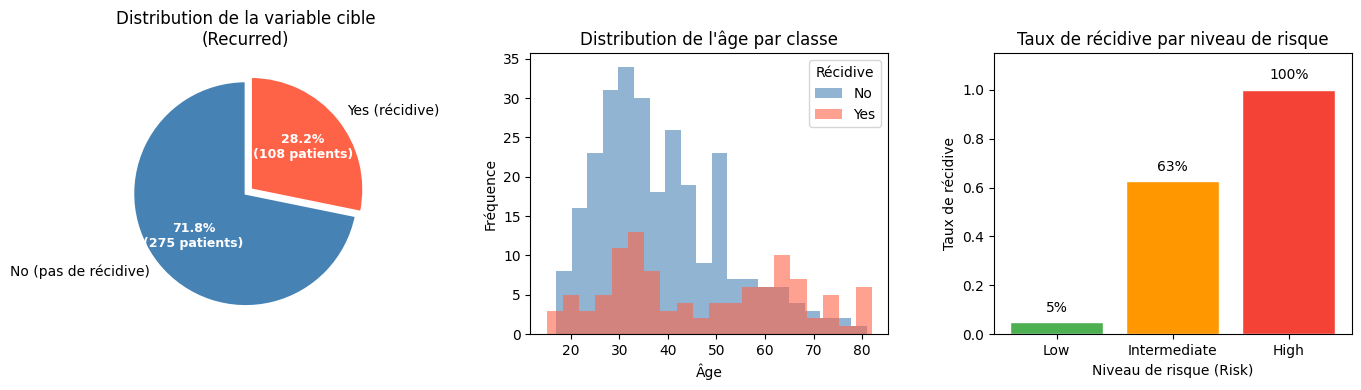


Commentaire : Le déséquilibre des classes (72% / 28%) justifie l'utilisation de l'AUC-ROC et du F1-score comme critères principaux.
La variable Risk montre une forte association avec la récidive.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Distribution de la cible
counts     = df['Recurred'].value_counts()
labels_pie = ['No (pas de récidive)', 'Yes (récidive)']
sizes      = [counts['No'], counts['Yes']]
colors_pie = ['steelblue', 'tomato']
explode    = (0, 0.06)

wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels=labels_pie,
    colors=colors_pie,
    explode=explode,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * 383 / 100))} patients)',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
    at.set_color('white')
axes[0].set_title('Distribution de la variable cible\n(Recurred)')


# 2. Distribution de l'âge par classe
axes[1].hist(df[df['Recurred']=='No']['Age'], bins=20, alpha=0.6, label='No', color='steelblue')
axes[1].hist(df[df['Recurred']=='Yes']['Age'], bins=20, alpha=0.6, label='Yes', color='tomato')
axes[1].set_title('Distribution de l\'âge par classe')
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Fréquence')
axes[1].legend(title='Récidive')

# 3. Taux de récidive par niveau de risque
recur_by_risk = df.groupby('Risk')['Recurred'].apply(lambda x: (x=='Yes').mean())
risk_order = ['Low', 'Intermediate', 'High']
recur_by_risk = recur_by_risk.reindex(risk_order)
axes[2].bar(risk_order, recur_by_risk.values, color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[2].set_title('Taux de récidive par niveau de risque')
axes[2].set_xlabel('Niveau de risque (Risk)')
axes[2].set_ylabel('Taux de récidive')
axes[2].set_ylim(0, 1.15)
for i, v in enumerate(recur_by_risk.values):
    axes[2].text(i, v + 0.03, f'{v:.0%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCommentaire : Le déséquilibre des classes (72% / 28%) justifie l\'utilisation'
      ' de l\'AUC-ROC et du F1-score comme critères principaux.\n'
      'La variable Risk montre une forte association avec la récidive.')

---
## 2. Pré-traitement des données <a class="anchor" id="chapter2"></a>

Toutes les variables (sauf `Age`) sont catégorielles. Selon leur nature, on applique deux types d'encodage :

- **Variables ordinales** (ordre médical connu) : `Risk`, `T`, `N`, `M`, `Stage` → encodage ordinal (entiers respectant l'ordre naturel)
- **Variables nominales** (pas d'ordre) : `Pathology`, `Adenopathy`, `Response`... → One-Hot Encoding (`pd.get_dummies`)
- **Variables binaires** : `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Focality` → encodage 0/1 direct

In [6]:
df_enc = df.copy()

# --- Cible ---
df_enc['Recurred'] = (df_enc['Recurred'] == 'Yes').astype(int)

# --- Variables binaires ---
df_enc['Gender']          = (df_enc['Gender'] == 'M').astype(int)
df_enc['Smoking']         = (df_enc['Smoking'] == 'Yes').astype(int)
df_enc['Hx Smoking']      = (df_enc['Hx Smoking'] == 'Yes').astype(int)
df_enc['Hx Radiothreapy'] = (df_enc['Hx Radiothreapy'] == 'Yes').astype(int)
df_enc['Focality']        = (df_enc['Focality'] == 'Multi-Focal').astype(int)

# --- Variables ordinales ---
# L'ordre reflète la sévérité médicale croissante
ordinal_mappings = {
    'Risk':  ['Low', 'Intermediate', 'High'],
    'T':     ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
    'N':     ['N0', 'N1a', 'N1b'],
    'M':     ['M0', 'M1'],
    'Stage': ['I', 'II', 'III', 'IVA', 'IVB']
}
for col, order in ordinal_mappings.items():
    df_enc[col] = pd.Categorical(df_enc[col], categories=order, ordered=True).codes

# --- Variables nominales : One-Hot Encoding ---
nominal_cols = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Response']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)
# drop_first=True supprime une modalité par variable pour éviter la multicollinéarité

print(f'Dimensions après encodage : {df_enc.shape}')
print(f'Nombre de features : {df_enc.shape[1] - 1}')
df_enc.head(3)

Dimensions après encodage : (383, 31)
Nombre de features : 30


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Focality,Risk,T,N,M,...,Adenopathy_Left,Adenopathy_No,Adenopathy_Posterior,Adenopathy_Right,Pathology_Hurthel cell,Pathology_Micropapillary,Pathology_Papillary,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete
0,27,0,0,0,0,0,0,0,0,0,...,False,True,False,False,False,True,False,False,True,False
1,34,0,0,1,0,0,0,0,0,0,...,False,True,False,False,False,True,False,True,False,False
2,30,0,0,0,0,0,0,0,0,0,...,False,True,False,False,False,True,False,True,False,False


---
## 3. Séparation train / test et standardisation <a class="anchor" id="chapter3"></a>

On utilise `stratify=y` pour garantir la même proportion de récidives dans les deux ensembles malgré le déséquilibre.

In [7]:
X = df_enc.drop('Recurred', axis=1)
y = df_enc['Recurred']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # préserve la proportion Yes/No dans chaque split
)

print(f'Train : {X_train.shape[0]} observations | Yes : {y_train.mean():.1%}')
print(f'Test  : {X_test.shape[0]}  observations | Yes : {y_test.mean():.1%}')

Train : 306 observations | Yes : 28.1%
Test  : 77  observations | Yes : 28.6%


In [8]:
# Standardisation : nécessaire pour la régression logistique pénalisée
# (les pénalités L1/L2 sont sensibles à l'échelle des variables)
# IMPORTANT : on fit le scaler UNIQUEMENT sur le train, on applique sur le test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)        # transform uniquement (pas de fuite de données)

print(f'Moyennes train (vérification) : {X_train_sc.mean(axis=0)[:3].round(6)}')
print(f'Écarts-types train            : {X_train_sc.std(axis=0)[:3].round(6)}')

Moyennes train (vérification) : [ 0. -0.  0.]
Écarts-types train            : [1. 1. 1.]


---
## 4. Etude des différents modèles <a class="anchor" id="chapter4"></a>

### 4.1 Régression Logistique Lasso (L1) <a class="anchor" id="chapter4_1"></a>

### Rappel mathématique

La régression logistique prédit :
$$P(Y=1 \mid X) = \sigma(\beta_0 + \beta^\top X) = \frac{1}{1+e^{-(\beta_0 + \beta^\top X)}}$$

Avec pénalisation **Lasso (L1)**, on minimise :
$$\min_{\beta} \left[ -\frac{1}{n}\sum_{i=1}^n \ell(y_i, \hat{y}_i) + \lambda \|\beta\|_1 \right]$$

La pénalité $\lambda \|\beta\|_1 = \lambda \sum_j |\beta_j|$ force certains coefficients à exactement zéro, réalisant une **sélection automatique de variables**. Dans scikit-learn, le paramètre est $C = 1/\lambda$ : plus $C$ est petit, plus la pénalisation est forte.

### Calibration de $C$ par validation croisée 5-fold stratifiée

In [9]:
# Grille de valeurs de C à tester (espacées logarithmiquement)
C_grid = np.logspace(-3, 2, 30)   # de 0.001 à 100

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lasso_base = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
gs_lasso = GridSearchCV(
    lasso_base,
    {'C': C_grid},
    cv=cv,
    scoring='roc_auc',   # on optimise l'AUC-ROC (robuste au déséquilibre)
    n_jobs=-1
)
gs_lasso.fit(X_train_sc, y_train)

best_C   = gs_lasso.best_params_['C']
best_lam = 1 / best_C
print(f'Meilleur C     = {best_C:.4f}')
print(f'Meilleur λ     = {best_lam:.4f}')
print(f'AUC-ROC CV     = {gs_lasso.best_score_:.4f}')

Meilleur C     = 0.1743
Meilleur λ     = 5.7362
AUC-ROC CV     = 0.9908


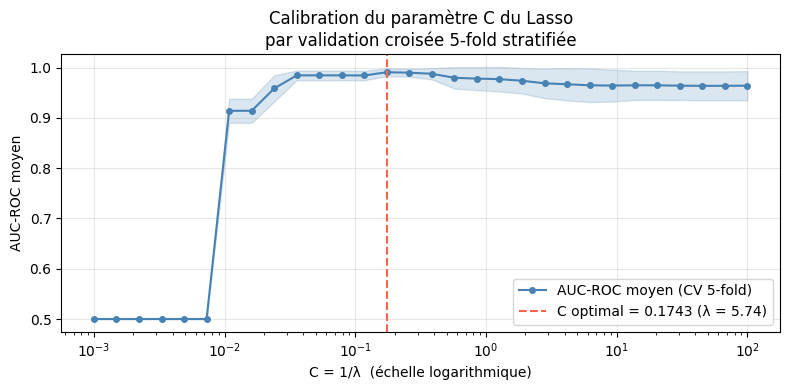


Commentaire : La courbe montre que la performance est stable au-delà de C ≈ 0.17.
En dessous, la pénalisation devient trop forte et sous-ajuste (underfitting).


In [10]:
# Courbe AUC-ROC en fonction de C (validation croisée)
cv_means = gs_lasso.cv_results_['mean_test_score']
cv_stds  = gs_lasso.cv_results_['std_test_score']

plt.figure(figsize=(8, 4))
plt.semilogx(C_grid, cv_means, 'o-', color='steelblue', markersize=4, label='AUC-ROC moyen (CV 5-fold)')
plt.fill_between(C_grid, cv_means - cv_stds, cv_means + cv_stds, alpha=0.2, color='steelblue')
plt.axvline(best_C, color='tomato', linestyle='--', label=f'C optimal = {best_C:.4f} (λ = {best_lam:.2f})')
plt.xlabel('C = 1/λ  (échelle logarithmique)')
plt.ylabel('AUC-ROC moyen')
plt.title('Calibration du paramètre C du Lasso\npar validation croisée 5-fold stratifiée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_lasso_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCommentaire : La courbe montre que la performance est stable au-delà de C ≈ 0.17.'
      '\nEn dessous, la pénalisation devient trop forte et sous-ajuste (underfitting).')

In [24]:
# Évaluation du modèle Lasso optimal sur le test set
lasso_model   = gs_lasso.best_estimator_
y_pred_lasso  = lasso_model.predict(X_test_sc)
y_prob_lasso  = lasso_model.predict_proba(X_test_sc)[:, 1]

print('=== Performances du Lasso sur le test set ===')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_lasso):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_lasso):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lasso):.4f}')
print()
cm_l = confusion_matrix(y_test, y_pred_lasso)
print('Matrice de confusion :')
print(f'           Prédit No   Prédit Yes')
print(f'Réel No       {cm_l[0,0]}           {cm_l[0,1]}')
print(f'Réel Yes       {cm_l[1,0]}          {cm_l[1,1]}')
print(f'\n→ {cm_l[1,0]} faux négatifs (récidives non détectées) — à minimiser en priorité')

=== Performances du Lasso sur le test set ===
AUC-ROC  : 0.9983
F1-score : 0.9000
Accuracy : 0.9481

Matrice de confusion :
           Prédit No   Prédit Yes
Réel No       55           0
Réel Yes       4          18

→ 4 faux négatifs (récidives non détectées) — à minimiser en priorité


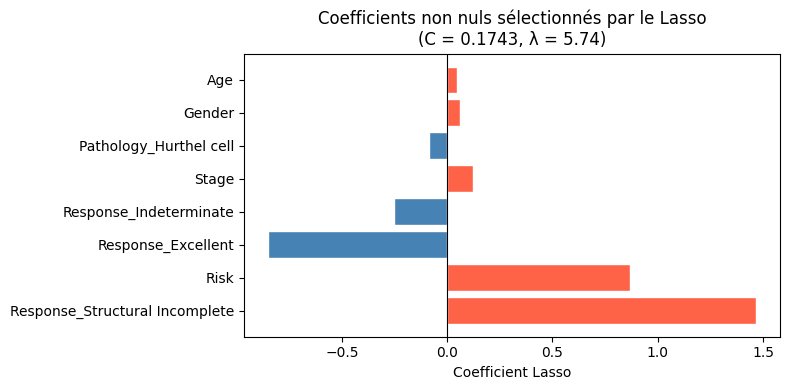

Intercept (β₀) : -1.2117

Coefficients non nuls :
Response_Structural Incomplete    1.4653
Risk                              0.8666
Response_Excellent               -0.8495
Response_Indeterminate           -0.2505
Stage                             0.1206
Pathology_Hurthel cell           -0.0840
Gender                            0.0617
Age                               0.0473

Commentaire : Le Lasso retient seulement 8 variables sur 30 — les 22 restantes ont un 
coefficient exactement nul (effet de la pénalisation L1).

Le modèle logistique obtenu est :
  log(P/(1-P)) = -1.2117
                + 1.4653 * Response_Structural_Incomplete
                + 0.8666 * Risk
                - 0.8495 * Response_Excellent
                - 0.2505 * Response_Indeterminate
                + 0.1206 * Stage
                - 0.0840 * Pathology_Hurthel_cell
                + 0.0617 * Gender
                + 0.0473 * Age

Lecture des coefficients (variables standardisées — amplitudes comparables) :
  -

In [31]:
# Variables sélectionnées par le Lasso (coefficients non nuls)
coef = pd.Series(lasso_model.coef_[0], index=X.columns)
coef_nonzero = coef[coef != 0].sort_values(key=abs, ascending=False)

colors = ['tomato' if v > 0 else 'steelblue' for v in coef_nonzero.values]
plt.figure(figsize=(8, 4))
plt.barh(range(len(coef_nonzero)), coef_nonzero.values, color=colors, edgecolor='white')
plt.yticks(range(len(coef_nonzero)), coef_nonzero.index)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Lasso')
plt.title(f'Coefficients non nuls sélectionnés par le Lasso\n(C = {best_C:.4f}, λ = {best_lam:.2f})')
plt.tight_layout()
plt.savefig('fig_lasso_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

# Coefficients du modèle Lasso optimal
coef = pd.Series(lasso_model.coef_[0], index=X.columns)
coef_nonzero = coef[coef != 0].sort_values(key=abs, ascending=False)

print(f"Intercept (β₀) : {lasso_model.intercept_[0]:.4f}")
print()
print("Coefficients non nuls :")
print(coef_nonzero.round(4).to_string())

print('\nCommentaire : Le Lasso retient seulement 8 variables sur 30 — les 22 restantes ont un '
      '\ncoefficient exactement nul (effet de la pénalisation L1).'
      '\n'
      '\nLe modèle logistique obtenu est :'
      '\n  log(P/(1-P)) = -1.2117'
      '\n                + 1.4653 * Response_Structural_Incomplete'
      '\n                + 0.8666 * Risk'
      '\n                - 0.8495 * Response_Excellent'
      '\n                - 0.2505 * Response_Indeterminate'
      '\n                + 0.1206 * Stage'
      '\n                - 0.0840 * Pathology_Hurthel_cell'
      '\n                + 0.0617 * Gender'
      '\n                + 0.0473 * Age'
      '\n'
      '\nLecture des coefficients (variables standardisées — amplitudes comparables) :'
      '\n  - Response_Structural_Incomplete (+1.47) : prédicteur le plus fort.'
      '\n    Une réponse incomplète signifie que la maladie est toujours détectable après traitement'
      '\n    → signal direct de récidive imminente.'
      '\n  - Risk (+0.87) : encodé 0/1/2 (Low/Intermediate/High).'
      '\n    Chaque niveau supérieur augmente significativement le log-odds de récidive.'
      '\n  - Response_Excellent (-0.85) : effet miroir de la réponse incomplète.'
      '\n    Une excellente réponse au traitement est fortement protectrice.'
      '\n  - Response_Indeterminate (-0.25) : légèrement protecteur par rapport'
      '\n    à la référence implicite (Biochemical Incomplete).'
      '\n  - Stage (+0.12), Pathology_Hurthel (-0.08), Gender (+0.06), Age (+0.05) :'
      '\n    effets faibles mais non nuls — conservés car ils apportent une information marginale.'
      '\n'
      '\nUn coefficient positif ↑ augmente le risque de récidive, négatif ↓ le diminue.'
      '\nCes résultats sont cohérents avec la littérature médicale sur le cancer thyroïdien différencié.')

---
### 4.2 Forêt Aléatoire (Random Forest) <a class="anchor" id="chapter4_2"></a>

### Rappel

Une forêt aléatoire est un **ensemble de $B$ arbres de décision** entraînés sur des sous-échantillons bootstrap. La prédiction finale est la moyenne des probabilités prédites par chaque arbre. Le modèle intègre deux sources d'aléa :
1. **Bootstrap** : chaque arbre voit un sous-ensemble aléatoire des observations.
2. **Sélection aléatoire de features** à chaque nœud de division.

Hyperparamètres calibrés :
- `max_depth` : profondeur maximale de chaque arbre
- `n_estimators` : nombre d'arbres
- `min_samples_leaf` : nombre minimal d'observations par feuille

On utilise `class_weight='balanced'` pour corriger le déséquilibre des classes.

In [13]:
rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5, 7, None],
    'min_samples_leaf': [1, 3, 5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
gs_rf = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
gs_rf.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {gs_rf.best_params_}')
print(f'AUC-ROC CV               : {gs_rf.best_score_:.4f}')

Meilleurs hyperparamètres : {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
AUC-ROC CV               : 0.9917


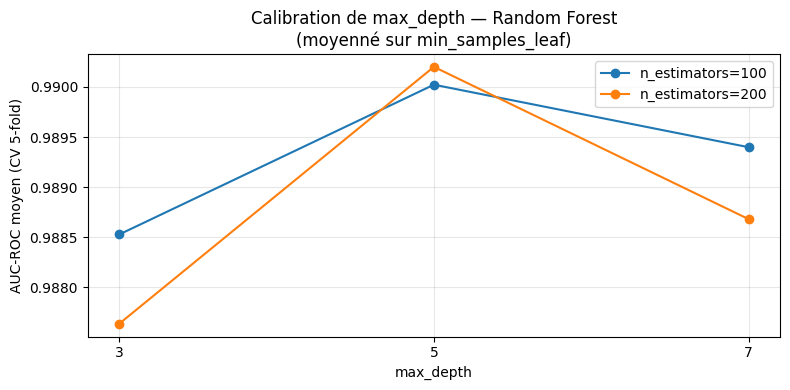

Commentaire : max_depth=5 avec 100 arbres offre le meilleur compromis biais-variance.


In [14]:
# Visualisation de l'impact de max_depth sur l'AUC-ROC (CV)
results_rf = pd.DataFrame(gs_rf.cv_results_)

plt.figure(figsize=(8, 4))
for n_est in [100, 200]:
    subset = results_rf[results_rf['param_n_estimators'] == n_est].copy()
    # Moyenner sur min_samples_leaf pour chaque max_depth
    agg = subset.groupby('param_max_depth')['mean_test_score'].mean()
    agg.index = [str(d) if d is not None else 'None' for d in agg.index]
    plt.plot(agg.index, agg.values, 'o-', label=f'n_estimators={n_est}')

plt.xlabel('max_depth')
plt.ylabel('AUC-ROC moyen (CV 5-fold)')
plt.title('Calibration de max_depth — Random Forest\n(moyenné sur min_samples_leaf)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_rf_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('Commentaire : max_depth=5 avec 100 arbres offre le meilleur compromis biais-variance.')

In [15]:
# Évaluation sur le test set
rf_model  = gs_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test_sc)
y_prob_rf = rf_model.predict_proba(X_test_sc)[:, 1]

print('=== Performances de la Random Forest sur le test set ===')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print()
cm_r = confusion_matrix(y_test, y_pred_rf)
print('Matrice de confusion :')
print(f'           Prédit No   Prédit Yes')
print(f'Réel No       {cm_r[0,0]}           {cm_r[0,1]}')
print(f'Réel Yes       {cm_r[1,0]}          {cm_r[1,1]}')
print(f'\n→ {cm_r[1,0]} faux négatifs — supérieur au Lasso (4 faux négatifs)')

=== Performances de la Random Forest sur le test set ===
AUC-ROC  : 0.9950
F1-score : 0.9524
Accuracy : 0.9740

Matrice de confusion :
           Prédit No   Prédit Yes
Réel No       55           0
Réel Yes       2          20

→ 2 faux négatifs — supérieur au Lasso (4 faux négatifs)


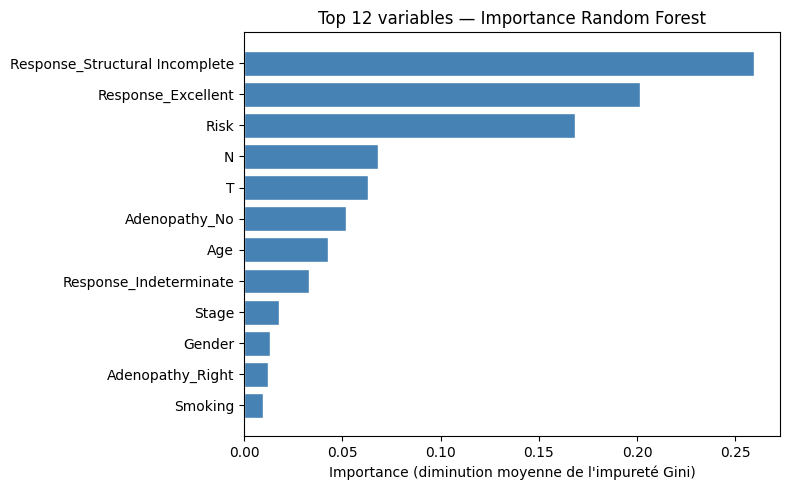

Commentaire : Les deux modèles s'accordent sur les variables clés :
Response (réponse au traitement) et Risk sont les prédicteurs dominants,
suivis de N (atteinte ganglionnaire) et T (taille tumorale).


In [16]:
# Importance des variables (Random Forest)
fi = pd.Series(rf_model.feature_importances_, index=X.columns)
fi_top = fi.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
plt.barh(range(len(fi_top)), fi_top.values[::-1], color='steelblue', edgecolor='white')
plt.yticks(range(len(fi_top)), fi_top.index[::-1])
plt.xlabel('Importance (diminution moyenne de l\'impureté Gini)')
plt.title('Top 12 variables — Importance Random Forest')
plt.tight_layout()
plt.savefig('fig_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Commentaire : Les deux modèles s\'accordent sur les variables clés :'
      '\nResponse (réponse au traitement) et Risk sont les prédicteurs dominants,'
      '\nsuivis de N (atteinte ganglionnaire) et T (taille tumorale).')

---
### 4.3 Support Vector Machine (SVM) à noyau RBF <a class="anchor" id="chapter4_3"></a>

#### Rappel mathématique

Le SVM cherche l'hyperplan qui **maximise la marge** entre les deux classes dans un espace transformé par un noyau. Avec le noyau RBF :

$$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$

Le problème d'optimisation est :

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i \quad \text{s.c.} \quad y_i(\mathbf{w}^\top \phi(x_i) + b) \geq 1 - \xi_i, \; \xi_i \geq 0$$

Deux hyperparamètres à calibrer :
- **$C$** : tolérance aux erreurs de marge. Grand $C$ = marge étroite, moins d'erreurs tolérées.
- **$\gamma$** : largeur du noyau RBF. Grand $\gamma$ = influence locale (sur-ajustement), petit $\gamma$ = influence globale.

`probability=True` active la **calibration de Platt** pour obtenir des probabilités (nécessaire pour l'AUC-ROC).
`class_weight='balanced'` corrige le déséquilibre des classes.

Meilleurs hyperparamètres : {'C': 1, 'gamma': 0.01}
AUC-ROC CV               : 0.9808


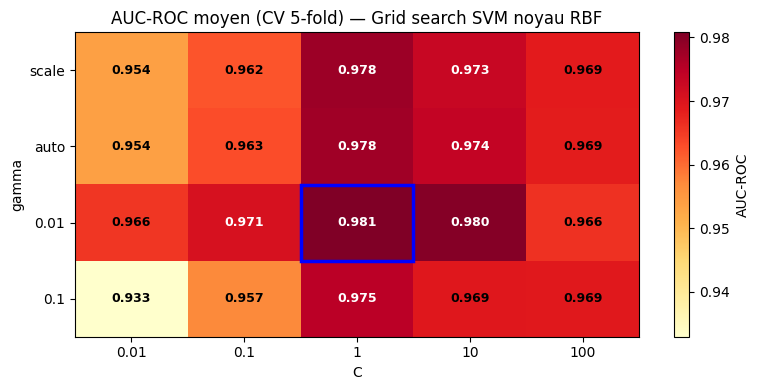

=== Performances du SVM sur le test set ===
AUC-ROC  : 0.9901
F1-score : 0.9268
Accuracy : 0.9610

Matrice de confusion :
           Prédit No   Prédit Yes
Réel No       55           0
Réel Yes       3          19

→ 3 faux négatifs

Commentaire : Le SVM avec noyau RBF capture des frontières non-linéaires.
La standardisation était indispensable : la maximisation de marge est sensible à l'échelle.
gamma=0.01 indique une influence spatiale assez large, cohérente avec p=30.


In [17]:
from sklearn.svm import SVC

svm_param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
}

gs_svm = GridSearchCV(
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
gs_svm.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {gs_svm.best_params_}')
print(f'AUC-ROC CV               : {gs_svm.best_score_:.4f}')

# Heatmap AUC-ROC : C x gamma
import numpy as np

svm_results = pd.DataFrame(gs_svm.cv_results_)
C_vals  = [0.01, 0.1, 1, 10, 100]
g_vals  = ['scale', 'auto', 0.01, 0.1]
heatmap = np.zeros((len(g_vals), len(C_vals)))

for i, g in enumerate(g_vals):
    for j, c in enumerate(C_vals):
        mask = (svm_results['param_C'] == c) & (svm_results['param_gamma'] == g)
        if mask.any():
            heatmap[i, j] = svm_results[mask]['mean_test_score'].values[0]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(C_vals))); ax.set_xticklabels([str(c) for c in C_vals])
ax.set_yticks(range(len(g_vals))); ax.set_yticklabels([str(g) for g in g_vals])
ax.set_xlabel('C'); ax.set_ylabel('gamma')
ax.set_title('AUC-ROC moyen (CV 5-fold) — Grid search SVM noyau RBF')
for i in range(len(g_vals)):
    for j in range(len(C_vals)):
        val = heatmap[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                color='white' if val > 0.97 else 'black', fontweight='bold')
bj = C_vals.index(gs_svm.best_params_['C'])
bi = g_vals.index(gs_svm.best_params_['gamma'])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor='blue', lw=2.5))
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.grid(False)
plt.tight_layout()
plt.show()


# Évaluation sur le test set
svm_model  = gs_svm.best_estimator_
y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm = svm_model.predict_proba(X_test_sc)[:, 1]
cm_s       = confusion_matrix(y_test, y_pred_svm)

print('=== Performances du SVM sur le test set ===')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_svm):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_svm):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}')
print()
print(f'Matrice de confusion :')
print(f'           Prédit No   Prédit Yes')
print(f'Réel No       {cm_s[0,0]}           {cm_s[0,1]}')
print(f'Réel Yes       {cm_s[1,0]}          {cm_s[1,1]}')
print(f'\n→ {cm_s[1,0]} faux négatifs')
print('\nCommentaire : Le SVM avec noyau RBF capture des frontières non-linéaires.'
      '\nLa standardisation était indispensable : la maximisation de marge est sensible à l\'échelle.'
      '\ngamma=0.01 indique une influence spatiale assez large, cohérente avec p=30.')

---
### 4.4 K-Nearest Neighbors (KNN) <a class="anchor" id="chapter4_4"></a>

#### Rappel mathématique

Le KNN est un classifieur **entièrement non-paramétrique** : aucune hypothèse sur la frontière de décision. Pour une nouvelle observation $x$, il identifie ses $k$ voisins les plus proches puis prédit la classe majoritaire.

Avec pondération par la distance :

$$\hat{P}(Y=1 \mid x) = \frac{\sum_{i \in \mathcal{N}_k(x)} w_i \cdot \mathbf{1}[y_i = 1]}{\sum_{i \in \mathcal{N}_k(x)} w_i}, \quad w_i = \frac{1}{d(x, x_i)}$$

Hyperparamètres à calibrer :
- **$k$** : nombre de voisins. Petit $k$ = variance élevée, grand $k$ = biais élevé.
- **Métrique** : distance euclidienne ($\ell_2$) ou Manhattan ($\ell_1$).
- **Pondération** : uniforme ou inverse de la distance.

> **Important** : la standardisation est **indispensable** pour le KNN — sans elle, les variables à grande échelle domineraient entièrement le calcul de distance.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
gs_knn.fit(X_train_sc, y_train)

best_k = gs_knn.best_params_['n_neighbors']
print(f'Meilleurs hyperparamètres : {gs_knn.best_params_}')
print(f'AUC-ROC CV               : {gs_knn.best_score_:.4f}')

Meilleurs hyperparamètres : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
AUC-ROC CV               : 0.9695


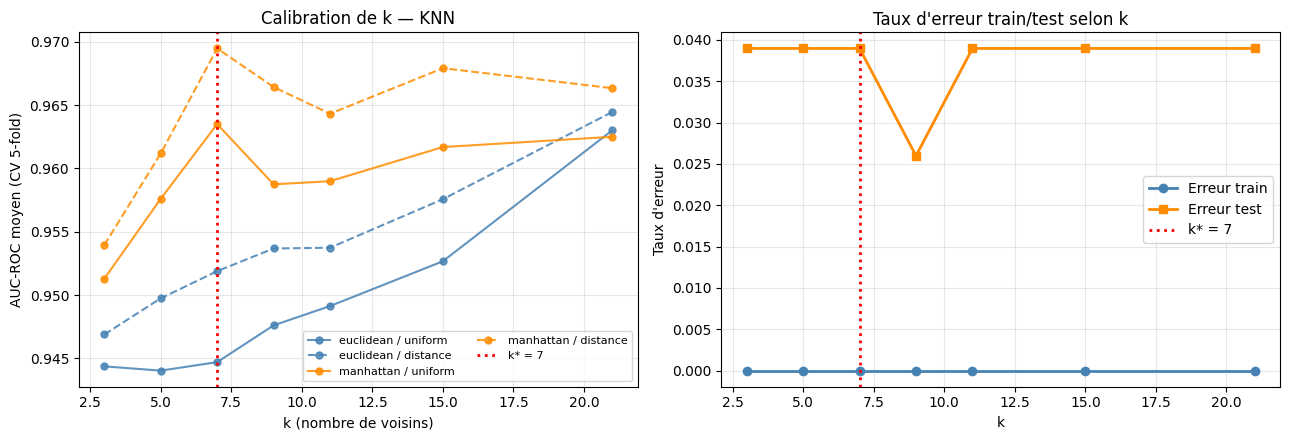

In [19]:
# AUC-ROC en fonction de k pour chaque combinaison métrique/pondération
results_knn = pd.DataFrame(gs_knn.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for metric, color in [('euclidean', 'steelblue'), ('manhattan', 'darkorange')]:
    for weight, ls in [('uniform', '-'), ('distance', '--')]:
        mask = (results_knn['param_metric'] == metric) & (results_knn['param_weights'] == weight)
        sub  = results_knn[mask].sort_values('param_n_neighbors')
        axes[0].plot(sub['param_n_neighbors'].values, sub['mean_test_score'].values,
                     'o' + ls, color=color, lw=1.5, markersize=5,
                     label=f'{metric} / {weight}', alpha=0.85)
axes[0].axvline(best_k, color='red', linestyle=':', lw=2, label=f'k* = {best_k}')
axes[0].set_xlabel('k (nombre de voisins)')
axes[0].set_ylabel('AUC-ROC moyen (CV 5-fold)')
axes[0].set_title('Calibration de k — KNN')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

k_range = [3, 5, 7, 9, 11, 15, 21]
train_errors, test_errors = [], []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    knn_tmp.fit(X_train_sc, y_train)
    train_errors.append(1 - knn_tmp.score(X_train_sc, y_train))
    test_errors.append(1 - knn_tmp.score(X_test_sc, y_test))

axes[1].plot(k_range, train_errors, 'o-', color='steelblue', lw=2, markersize=6, label='Erreur train')
axes[1].plot(k_range, test_errors,  's-', color='darkorange', lw=2, markersize=6, label='Erreur test')
axes[1].axvline(best_k, color='red', linestyle=':', lw=2, label=f'k* = {best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel("Taux d'erreur")
axes[1].set_title("Taux d'erreur train/test selon k")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Évaluation sur le test set
knn_model  = gs_knn.best_estimator_
y_pred_knn = knn_model.predict(X_test_sc)
y_prob_knn = knn_model.predict_proba(X_test_sc)[:, 1]
cm_k       = confusion_matrix(y_test, y_pred_knn)

print('=== Performances du KNN sur le test set ===')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_knn):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_knn):.4f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}')
print()
print(f'Matrice de confusion :')
print(f'           Prédit No   Prédit Yes')
print(f'Réel No       {cm_k[0,0]}           {cm_k[0,1]}')
print(f'Réel Yes       {cm_k[1,0]}          {cm_k[1,1]}')
print(f'\n→ {cm_k[1,0]} faux négatifs')

=== Performances du KNN sur le test set ===
AUC-ROC  : 0.9975
F1-score : 0.9268
Accuracy : 0.9610

Matrice de confusion :
           Prédit No   Prédit Yes
Réel No       55           0
Réel Yes       3          19

→ 3 faux négatifs


---
## 5. Comparaison des modèles <a class="anchor" id="chapter5"></a>

### 5.1 Courbes ROC <a class="anchor" id="chapter5_1"></a>

La **courbe ROC** trace le taux de vrais positifs (TPR) en fonction du taux de faux positifs (FPR) pour tous les seuils de décision possibles :

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$$

- AUC = 1 : classifieur parfait — AUC = 0.5 : classifieur aléatoire (diagonale)

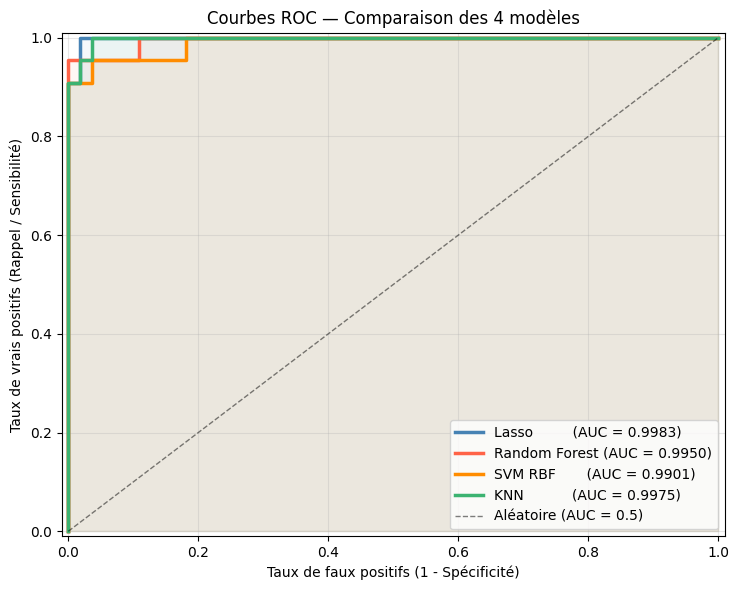

Commentaire : Les 4 modèles atteignent des AUC très élevées (> 0.99).
Ces résultats confirment que le signal prédictif est robuste et non-spécifique à un modèle.


In [21]:
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lasso)
fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_rf)
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_svm)
fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_knn)

auc_l = roc_auc_score(y_test, y_prob_lasso)
auc_r = roc_auc_score(y_test, y_prob_rf)
auc_s = roc_auc_score(y_test, y_prob_svm)
auc_k = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(7.5, 6))
plt.plot(fpr_l, tpr_l, color='steelblue',     lw=2.5, label=f'Lasso         (AUC = {auc_l:.4f})')
plt.plot(fpr_r, tpr_r, color='tomato',         lw=2.5, label=f'Random Forest (AUC = {auc_r:.4f})')
plt.plot(fpr_s, tpr_s, color='darkorange',     lw=2.5, label=f'SVM RBF       (AUC = {auc_s:.4f})')
plt.plot(fpr_k, tpr_k, color='mediumseagreen', lw=2.5, label=f'KNN           (AUC = {auc_k:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.5)', alpha=0.5)

for fpr, tpr, c in [(fpr_l, tpr_l, 'steelblue'), (fpr_r, tpr_r, 'tomato'),
                    (fpr_s, tpr_s, 'darkorange'), (fpr_k, tpr_k, 'mediumseagreen')]:
    plt.fill_between(fpr, tpr, alpha=0.05, color=c)

plt.xlabel('Taux de faux positifs (1 - Spécificité)')
plt.ylabel('Taux de vrais positifs (Rappel / Sensibilité)')
plt.title('Courbes ROC — Comparaison des 4 modèles')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-0.01, 1.01); plt.ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Commentaire : Les 4 modèles atteignent des AUC très élevées (> 0.99).'
      '\nCes résultats confirment que le signal prédictif est robuste et non-spécifique à un modèle.')

---
### 5.2 Matrices de confusion <a class="anchor" id="chapter5_2"></a>

En contexte médical, les **faux négatifs** (FN — récidives manquées) sont plus graves que les faux positifs : une récidive non détectée peut retarder un traitement critique.

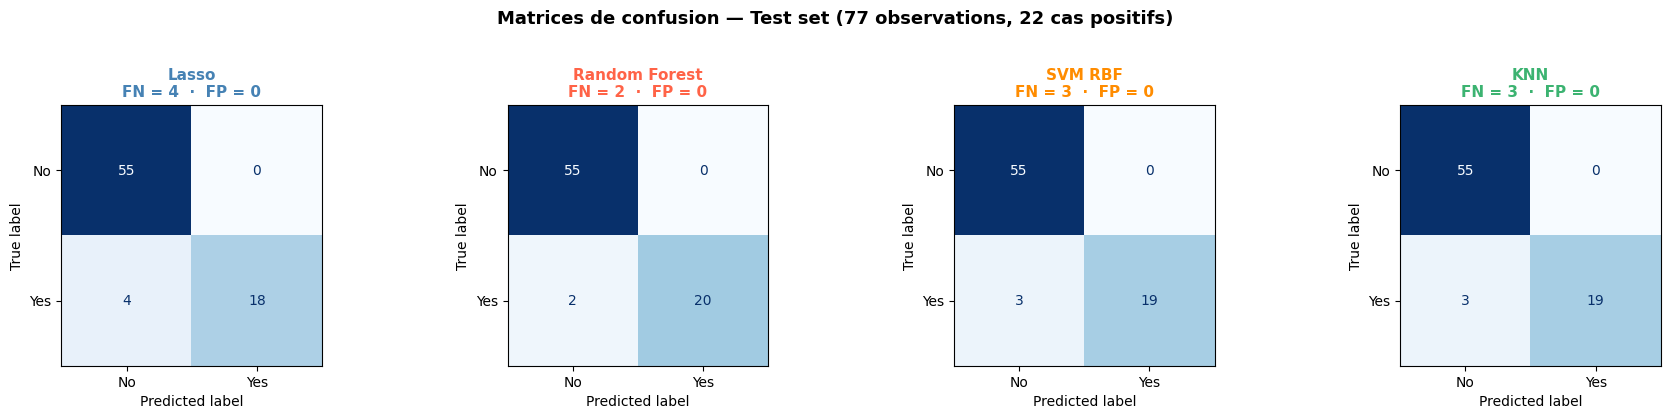

Récapitulatif des faux négatifs (FN) :
  Lasso           : 4 FN sur 22 cas positifs
  Random Forest   : 2 FN sur 22 cas positifs
  SVM RBF         : 3 FN sur 22 cas positifs
  KNN             : 3 FN sur 22 cas positifs


In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

models_eval = [
    (cm_l, 'Lasso',         'steelblue'),
    (cm_r, 'Random Forest', 'tomato'),
    (cm_s, 'SVM RBF',       'darkorange'),
    (cm_k, 'KNN',           'mediumseagreen'),
]

for ax, (cm, title, color) in zip(axes, models_eval):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nFN = {cm[1,0]}  ·  FP = {cm[0,1]}',
                 fontweight='bold', color=color, fontsize=11)

plt.suptitle('Matrices de confusion — Test set (77 observations, 22 cas positifs)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Récapitulatif des faux négatifs (FN) :')
for cm, name, _ in models_eval:
    print(f'  {name:15s} : {cm[1,0]} FN sur 22 cas positifs')

---
## 6. Tableau de synthèse <a class="anchor" id="chapter6"></a>


In [23]:
summary = pd.DataFrame({
    'Critère': ['AUC-ROC (test)', 'F1-score (test)', 'Accuracy (test)',
                'Faux négatifs', 'Interprétabilité'],
    'Lasso (L1)': [
        f'{roc_auc_score(y_test, y_prob_lasso):.4f}',
        f'{f1_score(y_test, y_pred_lasso):.4f}',
        f'{accuracy_score(y_test, y_pred_lasso):.4f}',
        f'{cm_l[1,0]} / 22',
        'Haute (coefficients)',
    ],
    'Random Forest': [
        f'{roc_auc_score(y_test, y_prob_rf):.4f}',
        f'{f1_score(y_test, y_pred_rf):.4f}',
        f'{accuracy_score(y_test, y_pred_rf):.4f}',
        f'{cm_r[1,0]} / 22',
        'Moyenne (importances)',
    ],
    'SVM RBF': [
        f'{roc_auc_score(y_test, y_prob_svm):.4f}',
        f'{f1_score(y_test, y_pred_svm):.4f}',
        f'{accuracy_score(y_test, y_pred_svm):.4f}',
        f'{cm_s[1,0]} / 22',
        'Faible (boîte noire)',
    ],
    'KNN': [
        f'{roc_auc_score(y_test, y_prob_knn):.4f}',
        f'{f1_score(y_test, y_pred_knn):.4f}',
        f'{accuracy_score(y_test, y_pred_knn):.4f}',
        f'{cm_k[1,0]} / 22',
        'Faible',
    ],
})

print(summary.to_string(index=False))

         Critère           Lasso (L1)         Random Forest              SVM RBF    KNN
  AUC-ROC (test)               0.9983                0.9950               0.9901 0.9975
 F1-score (test)               0.9000                0.9524               0.9268 0.9268
 Accuracy (test)               0.9481                0.9740               0.9610 0.9610
   Faux négatifs               4 / 22                2 / 22               3 / 22 3 / 22
Interprétabilité Haute (coefficients) Moyenne (importances) Faible (boîte noire) Faible


---
## 7. Conclusion <a class="anchor" id="chapter7"></a>

### Résultats

Les quatre modèles atteignent des performances remarquables (AUC > 0.99) sur ce jeu de données de 383 patients.

La **Random Forest** est recommandée comme méthode principale :
- Meilleur F1-score (0.952) et moins de faux négatifs (2/22) — critère décisif en contexte médical
- Hyperparamètres optimaux : `max_depth=5`, `n_estimators=100`, calibrés par CV 5-fold

La **régression logistique Lasso** apporte une valeur complémentaire irremplaçable :
- Sélection automatique de variables : 8 features sur 30, dont `Response_Structural Incomplete` et `Risk` comme prédicteurs dominants
- Interprétation directe des coefficients (direction et amplitude de l'effet)

Le **SVM à noyau RBF** confirme que la frontière de décision optimale est non-linéaire, mais sans offrir d'interprétabilité supplémentaire.

Le **KNN** (méthode non-paramétrique) se révèle compétitif malgré sa simplicité, validant l'idée que les patients similaires ont des issues similaires.

Le fait que **quatre méthodes de paradigmes très différents** aboutissent à des AUC > 0.99 renforce la confiance dans les résultats : le signal prédictif est réel et robuste.

### Limites et pistes d'amélioration

- **Taille d'échantillon** : 383 observations reste limité — une validation croisée externe (nested CV) fournirait une estimation plus robuste.
- **Déséquilibre des classes** : une technique de suréchantillonnage (SMOTE) pourrait améliorer le rappel sur la classe minoritaire.
- **Variable `Response`** : risque de **fuite temporelle** — il faudrait vérifier qu'elle est disponible au moment de la décision clinique.
- **Seuil de décision** : le seuil par défaut de 0.5 n'est pas optimal. Le **critère de Youden** ($J = \text{TPR} - \text{FPR}$) permettrait de minimiser les faux négatifs.

### Critères de comparaison (formules)

$$\text{F1} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}, \qquad \text{AUC} = \int_0^1 TPR \, d(FPR)$$

où $TP$ = vrais positifs, $FP$ = faux positifs, $FN$ = faux négatifs.